---
# Predicting Income from US Census Data
## Binary classification on the UCI Adult dataset
---

This notebook works through a complete supervised classification pipeline on the UCI Adult census dataset. It covers the EDA, preprocessing, the development and comparison of four models, hyperparameter tuning, decision threshold selection, bootstrap confidence intervals and a fairness audit.

The accompanying written report is in `report.md`.

#**Definition of task:**

The task of this project is to predict whether a person surveyed in the 1994 US Census earns more than \$50,000 USD per year, given a set of features describing that person, using supervised classification.

> Given a feature vector $\mathbf{x} = (x_1, x_2, \ldots, x_p)$ describing a person, learn a function $f$ such that $\hat{y} = f(\mathbf{x}) \in \{0, 1\}$, where $y = 1$ indicates an income above \$50,000.

This is a classification problem instead of a regression because the target is a binary label rather than a continuous quantity. The model is trained on the provided training file and should be able to accurately classify unseen records in the held out test file.

The one property of this dataset that shapes everything downstream is that the target is imbalanced, with roughly one positive case in four. This is not severe enough to need resampling, but it is more than enough to make accuracy a poor guide to model quality, and it is the reason for the metric choices in the next section.

# Performance Measures:

### Primary Metric: ROC-AUC

$$\text{ROC-AUC} = P\big(\hat{p}(x^{+}) > \hat{p}(x^{-})\big)$$

ROC-AUC can be read as the probability that a randomly chosen positive case receives a higher score than a randomly chosen negative case. It has been selected as the primary metric for the following reasons:

- It is independent of any particular decision threshold. Comparing models at an arbitrary cutoff of 0.5 mixes together the quality of the ranking a model produces and the choice of where to cut that ranking, and those are two separate decisions that we want to make separately.
- It is not distorted by class imbalance in the way accuracy is, so a model that finds nobody scores exactly 0.5 rather than scoring 0.759.

### Secondary Metric: PR-AUC (Average Precision)

PR-AUC is reported alongside ROC-AUC for the following reasons:

- It ignores true negatives entirely, which makes it more informative when the positive class is rare and the abundant true negatives would otherwise flatter the model.
- It responds more sharply than ROC-AUC to changes in how the model handles the minority class, which is the class we actually care about here.

Precision, recall and F1 are also reported once a decision threshold has been chosen.

### A note on accuracy

Accuracy is reported throughout, but only to demonstrate that it is misleading. A model that predicts the majority class for every single record scores 75.9% accuracy on this dataset while identifying nobody at all. Rather than simply assert this, we include a dummy classifier that does exactly that in the model comparison, so the figure appears in the results table next to everything else.

### Evaluation Process:

Models are evaluated using 5 fold stratified cross validation on the training file. The training set is split into 5 equal parts (folds) where each fold serves as the validation set once while the other 4 are used for training. Stratification means each fold preserves the 24.1% positive rate, which removes an avoidable source of variance between folds.

The test file is kept entirely separate and used once, for final evaluation. It plays no part in model selection, hyperparameter tuning or threshold selection. All final test metrics are reported with bootstrap 95% confidence intervals, because a point estimate from a single test set hides real sampling uncertainty.

# Setup:

Initial imports. Everything here is from scikit-learn, pandas, numpy, matplotlib and seaborn, with no external dependencies.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     cross_val_predict, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, accuracy_score,
                             confusion_matrix, precision_recall_curve, roc_curve)

SEED = 42
np.random.seed(SEED)

FIG = Path('figures'); FIG.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

## Dataset:

The dataset was extracted from the 1994 US Census database by Barry Becker and is distributed by the [UCI Machine Learning Repository](https://doi.org/10.24432/C5XW20). Records were filtered by the dataset authors to individuals aged over 16, with a reported income above zero, a final sampling weight above 1, and more than zero hours worked per week.

### Training and test data:

| Property | Value |
|---|---|
| Training file | `adult.data`, 32,561 records |
| Test file | `adult.test`, 16,281 records |
| Columns | 15 (14 features + 1 target) |
| Missing values | 4,262 across 3 columns, marked with `?` |
| Target column | `income`, 1 if above \$50K |

The dataset ships with this predefined train and test split, and we use it rather than generating a fresh random split. Published results on this dataset use the canonical split, so reproducing it is what makes our figures comparable to the literature.

Two quirks of `adult.test` need handling on load. The first line is a comment rather than a data row, and the income labels in that file carry a trailing full stop that is absent from the training file.

### Features:

**Categorical features:**

| Feature | Description | Type |
|---|---|---|
| `workclass` | Employment type, 8 categories, 1,836 missing | Nominal |
| `education` | Highest education level, 16 categories | Nominal |
| `marital_status` | Marital status, 7 categories | Nominal |
| `occupation` | Occupation type, 14 categories, 1,843 missing | Nominal |
| `relationship` | Household role, 6 categories | Nominal |
| `race` | Race, 5 categories | Nominal |
| `sex` | Female (10,771) or Male (21,790) | Binary |
| `native_country` | Country of origin, 41 categories, 583 missing | Nominal |

**Numerical features:**

| Feature | Description |
|---|---|
| `age` | Age in years (17 to 90) |
| `fnlwgt` | Census final sampling weight |
| `education_num` | Education level as an integer (1 to 16) |
| `capital_gain` | Capital gains in USD |
| `capital_loss` | Capital losses in USD |
| `hours_per_week` | Usual hours worked per week (1 to 99) |

**Target variable:**

| Feature | Description |
|---|---|
| `income` | 1 if above \$50K, 0 otherwise |

We load both files up front, but all exploratory analysis below is performed on the training file only. Inspecting the test set to inform preprocessing choices would be a subtle form of leakage even though no model is fitted during that inspection.

In [2]:
BASE = ('https://raw.githubusercontent.com/HsiangHsu/Fair-Projection/'
        'main/data/UCI-Adult/')

COLS = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
        'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
        'hours_per_week', 'native_country', 'income']

# '?' is the missing-value marker; skipinitialspace strips the space after each comma.
train_raw = pd.read_csv(BASE + 'adult.data', header=None, names=COLS,
                        skipinitialspace=True, na_values=['?']).dropna(how='all')

# adult.test: skip the comment line, then strip the trailing '.' from every label.
test_raw = pd.read_csv(BASE + 'adult.test', header=None, names=COLS, skiprows=1,
                       skipinitialspace=True, na_values=['?']).dropna(how='all')
test_raw['income'] = test_raw['income'].str.rstrip('.')

for d in (train_raw, test_raw):
    d['income'] = (d['income'] == '>50K').astype(int)

print(f'Train: {train_raw.shape}   positive rate {train_raw.income.mean():.4f}')
print(f'Test:  {test_raw.shape}   positive rate {test_raw.income.mean():.4f}')
train_raw.head()

Train: (32561, 15)   positive rate 0.2408
Test:  (16281, 15)   positive rate 0.2362


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


The canonical split is roughly 2:1. The positive rate differs slightly between the two files, at 24.08% in training against 23.62% in test, because the split was made by the dataset authors rather than stratified by a modern library. This is worth keeping in mind because it means the test file is a genuinely separate sample rather than a reshuffle of the same pool.

From here on `df` refers to the training file only.

In [3]:
df = train_raw  # EDA operates on training data only

print('Shape:', df.shape)
print()
df.info()

Shape: (32561, 15)

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  int64
dtypes: int64(7), str(8)
memory usage: 3.7 MB


##First inspection:

Before any meaningful analysis, we check the basic properties of the dataset: shape, column data types and whether any values are missing.

The `.info()` method returns the data type of each column and the count of non-null values, which lets us identify missing data as well as which columns are numerical against categorical.

Observations:
- The training file contains 32,561 records across 15 columns.
- There are 6 numerical columns and 9 object (string) columns.
- Three columns contain missing values: `workclass`, `occupation` and `native_country`. Every other column is complete.

We now count those missing values precisely and check for exact duplicate rows.

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].to_frame('n_missing')
missing['pct'] = (missing['n_missing'] / len(df) * 100).round(2)
print(missing)
print()
print('Exact duplicate rows:', df.duplicated().sum())

                n_missing   pct
workclass            1836  5.64
occupation           1843  5.66
native_country        583  1.79

Exact duplicate rows: 24


Observations:
- Missingness is low, at 5.66% in the worst case (`occupation`), 5.64% for `workclass` and 1.79% for `native_country`.
- There are 24 exact duplicate rows out of 32,561, which is 0.07% of the data.

We have decided to keep the duplicates rather than drop them. In a census sample two people can genuinely share identical values across all 14 recorded attributes, and a 25 year old private sector high school graduate working 40 hours a week is not a rare profile. Treating them as data entry errors would require evidence that does not exist in the data.

We encode the target as 1 for `>50K` and 0 for `<=50K`, then check the class balance.

In [5]:
counts = df['income'].value_counts().sort_index()
print(counts)
print()
print(f'Positive class rate: {df["income"].mean():.4f}')
print(f'Accuracy from always predicting 0: {1 - df["income"].mean():.4f}')

income
0    24720
1     7841
Name: count, dtype: int64

Positive class rate: 0.2408
Accuracy from always predicting 0: 0.7592


### Target balance:

Observations:
- The class split is roughly 24% positive to 76% negative.
- A model that unconditionally predicts the negative class would score 75.9% accuracy.

This is the single most important fact about the dataset for evaluation purposes. Every accuracy figure in this notebook has to be read against a floor of 0.759 rather than against zero. An 85% accuracy result, which sounds respectable on its own, is only nine points above a model that does nothing at all.

# EDA:

The goal of this EDA is to understand the training data before building any models.

## Data Visualisation:

Using histograms we examine the distribution of each numerical feature. This helps us identify outliers, skewness and whether any transformations are required.

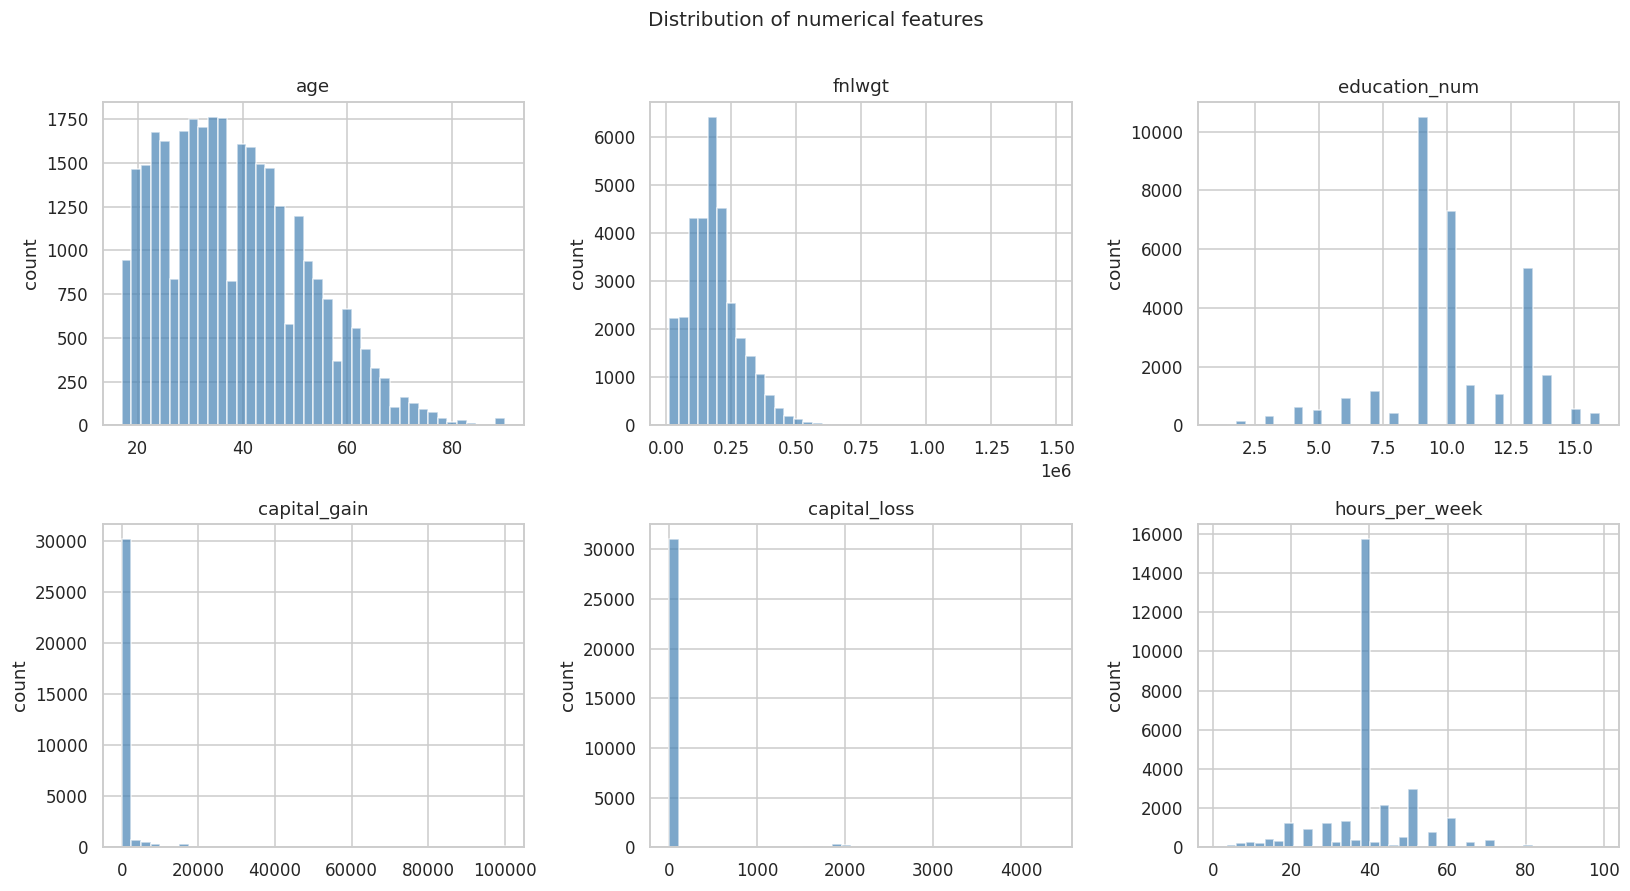

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols_all = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

for ax, col in zip(axes.ravel(), num_cols_all):
    ax.hist(df[col], bins=40, alpha=0.7, color='steelblue')
    ax.set_title(col); ax.set_ylabel('count')

plt.suptitle('Distribution of numerical features', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(FIG / 'fig1_numeric_distributions.png', bbox_inches='tight')
plt.show()

Observations:
- `age` is right skewed with a skewness of 0.56, spanning 17 to 90 with most of its mass between 20 and 50.
- `fnlwgt` is more heavily skewed at 1.45. It is the census sampling weight rather than a property of the person, and is examined separately below.
- `education_num` is discrete and multi modal with a large spike at 9 (high school graduate) and 10 (some college).
- `capital_gain` and `capital_loss` are extreme zero inflated distributions with skewness values of 11.95 and 4.59. These are quantified in the next cell.
- `hours_per_week` has a very sharp spike at exactly 40, as we would expect for a standard full time working week, with smaller clusters at 20 and 50.

In [7]:
print(f'capital_gain  == 0 : {(df.capital_gain == 0).mean():.3%}')
print(f'capital_loss  == 0 : {(df.capital_loss == 0).mean():.3%}')
print()
print(f'Positive rate when capital_gain >  0: {df.loc[df.capital_gain > 0, "income"].mean():.3f}')
print(f'Positive rate when capital_gain == 0: {df.loc[df.capital_gain == 0, "income"].mean():.3f}')

capital_gain  == 0 : 91.671%
capital_loss  == 0 : 95.335%

Positive rate when capital_gain >  0: 0.618
Positive rate when capital_gain == 0: 0.207


### Zero inflation in the capital columns:

91.7% of records have a capital gain of exactly zero and 95.3% have a capital loss of exactly zero. On a first pass these look close to constant columns and therefore close to useless, but the non zero minority turns out to be highly predictive.

Observations:
- 61.8% of people with any capital gain at all earn above \$50K, against 20.7% of those with none. This is a threefold difference in positive rate.
- The Pearson correlation of only 0.22 between `capital_gain` and the target badly understates this, because the relationship is a step change at zero rather than a linear slope, and a correlation coefficient measuring linear association is the wrong summary for it.

This has a direct consequence for model choice. A linear model has to fit a single coefficient to a variable that is zero 92% of the time and then ranges up to \$99,999 in the remainder, which is a poor representation of a relationship that is really "zero or not zero, then a weak slope". A tree based model can split on `capital_gain > 0` directly and treat the two sides separately. This is our first concrete reason to expect trees to outperform logistic regression here.

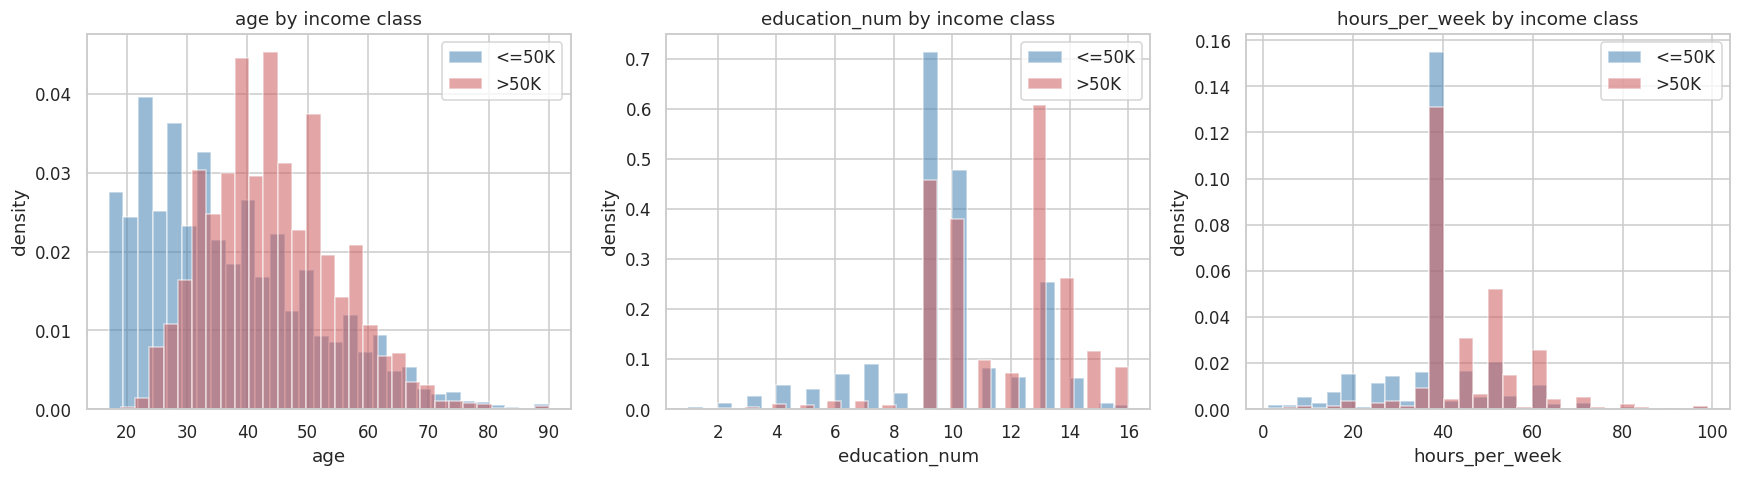

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ['age', 'education_num', 'hours_per_week']):
    for cls, label, colour in [(0, '<=50K', 'steelblue'), (1, '>50K', 'indianred')]:
        ax.hist(df.loc[df.income == cls, col], bins=30, alpha=0.55,
                label=label, density=True, color=colour)
    ax.set_title(f'{col} by income class')
    ax.set_xlabel(col); ax.set_ylabel('density'); ax.legend()

plt.tight_layout()
plt.savefig(FIG / 'fig2_numeric_by_class.png', bbox_inches='tight')
plt.show()

## Relationship between Features and Income:

### Numerical features vs. income:

Overlaying the class conditional densities lets us see how separable each feature is on its own. The high income group is shown in red.

Observations:
- The `age` distribution for the high income group is shifted right and far more concentrated in the 35 to 55 band. The relationship is clearly non monotonic, since the probability of high income rises through the thirties and forties and then falls again past retirement age. A linear model cannot represent a relationship of this shape without an explicit quadratic term being engineered in, whereas a tree can split on it directly.
- `education_num` shows strong separation, with the high income group concentrated at 13 (bachelors) and above.
- `hours_per_week` shows both classes spiking at 40, but with visibly more mass above 40 in the high income group.

No single feature separates the classes cleanly, which is expected and is the reason a model is warranted at all. Together with the step change in `capital_gain` above, the non monotonic age relationship is the second reason to expect tree based models to do well.

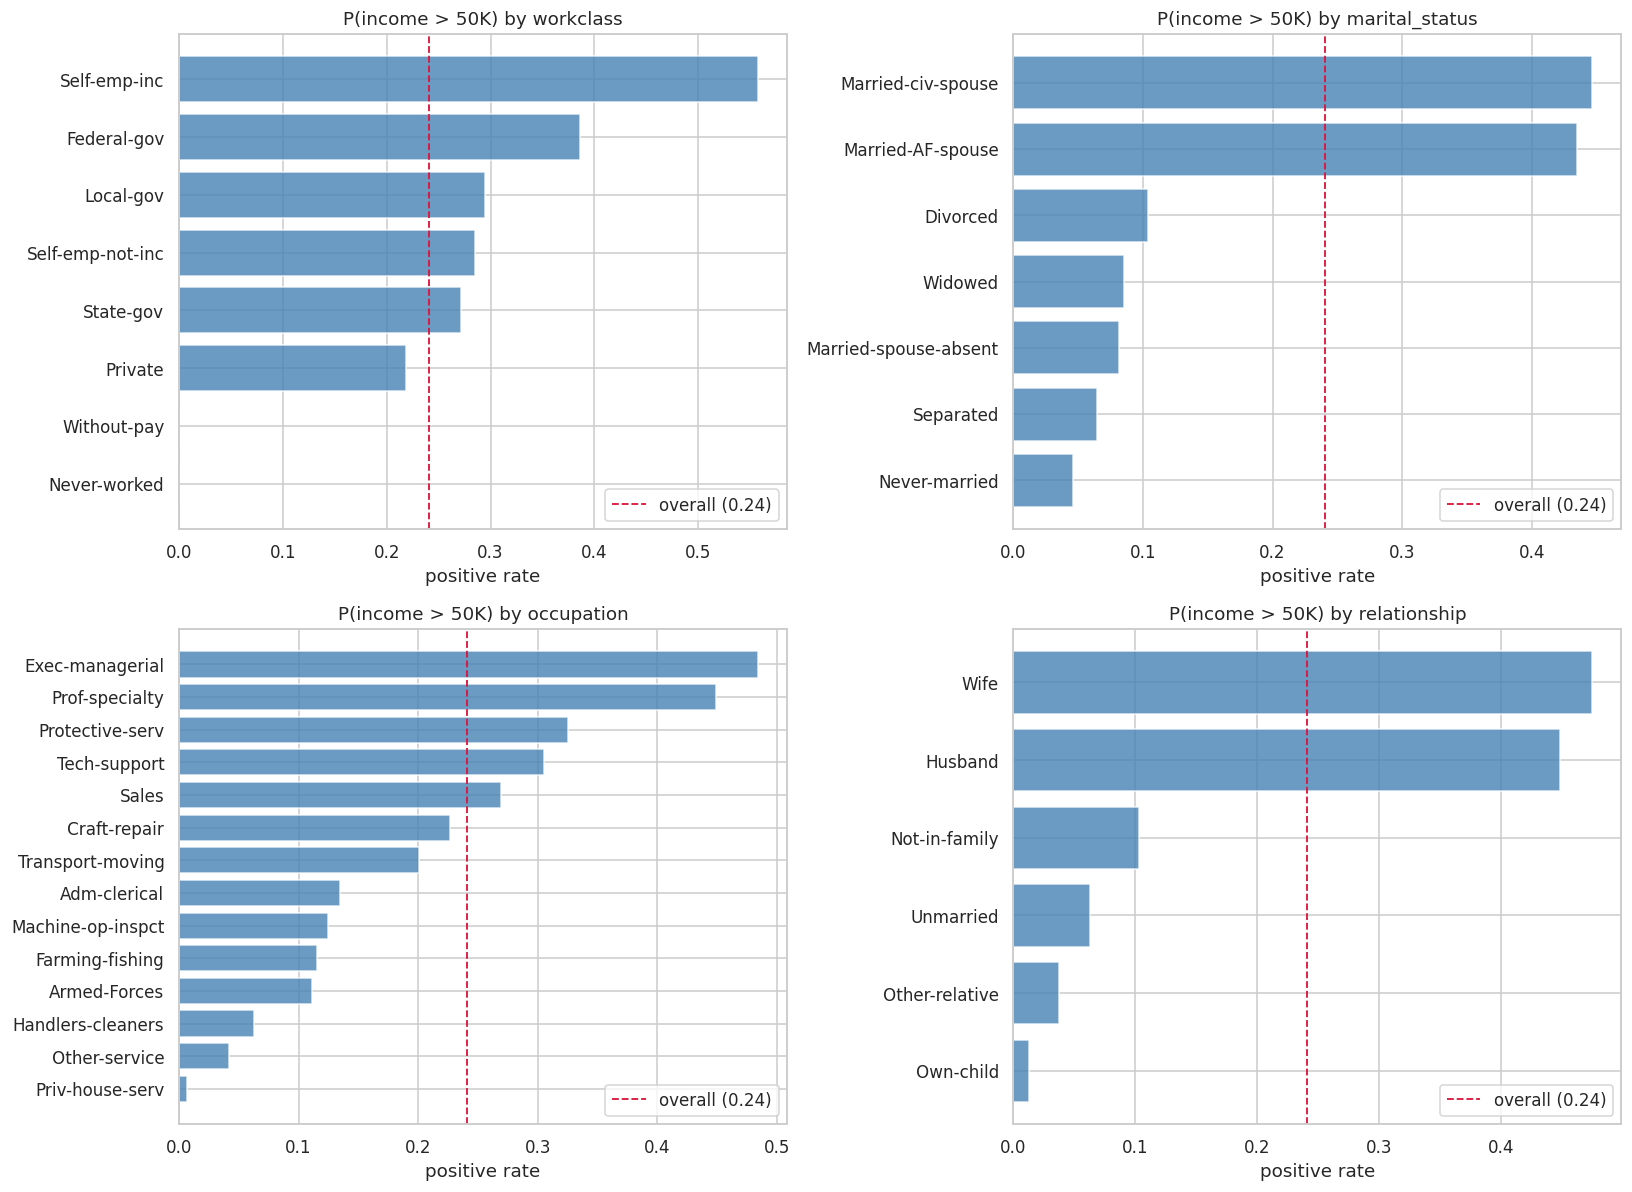

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, col in zip(axes.ravel(), ['workclass', 'marital_status', 'occupation', 'relationship']):
    rates = df.groupby(col)['income'].agg(['mean', 'size']).sort_values('mean')
    ax.barh(rates.index.astype(str), rates['mean'], color='steelblue', alpha=0.8)
    ax.axvline(df['income'].mean(), color='crimson', ls='--', lw=1.2,
               label=f'overall ({df["income"].mean():.2f})')
    ax.set_title(f'P(income > 50K) by {col}')
    ax.set_xlabel('positive rate'); ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIG / 'fig3_categorical_rates.png', bbox_inches='tight')
plt.show()

### Categorical features vs. income:

For categorical features we plot the positive rate within each category against the overall base rate, shown by the dashed line.

Observations:
- `marital_status` is the strongest single categorical predictor by a wide margin, with `Married-civ-spouse` sitting far above the base rate and `Never-married` far below it.
- `relationship` shows the same pattern, with `Husband` and `Wife` high and `Own-child` near zero. This is an early hint that the two features are largely redundant with one another.
- `occupation` separates sensibly, with `Exec-managerial` and `Prof-specialty` at the top and `Priv-house-serv` and `Other-service` at the bottom.
- `workclass` is weaker overall, although `Self-emp-inc` stands out clearly from the rest.

The strength of `marital_status` deserves scepticism rather than satisfaction. It is very unlikely to be causal in any useful sense. The dataset records individual income rather than household income, and in 1994 a married record was considerably more likely to describe a male primary earner than a female one. The feature is therefore doing demographic proxy work, standing in for household earning structure and, as the fairness audit later shows, for sex.

In [10]:
print('Unique education_num values per education label:')
print(df.groupby('education')['education_num'].nunique().value_counts())
print()
print(df[['education', 'education_num']].drop_duplicates()
        .sort_values('education_num').to_string(index=False))

Unique education_num values per education label:
education_num
1    16
Name: count, dtype: int64

   education  education_num
   Preschool              1
     1st-4th              2
     5th-6th              3
     7th-8th              4
         9th              5
        10th              6
        11th              7
        12th              8
     HS-grad              9
Some-college             10
   Assoc-voc             11
  Assoc-acdm             12
   Bachelors             13
     Masters             14
 Prof-school             15
   Doctorate             16


### Redundancy check: `education` and `education_num`

We check whether the two education columns carry the same information by counting how many distinct integer values map to each education label.

Observations:
- Every `education` label maps to exactly one `education_num` value, confirming that they are the same variable encoded twice, once nominally and once ordinally.
- Keeping both would add 15 one hot columns carrying no information at all.

We will drop the nominal `education` column and keep the ordinal `education_num`, because education has a genuine ordering that the integer encoding preserves and that one hot encoding would discard.

In [11]:
print(pd.crosstab(df['relationship'], df['sex']))
print()
print('fnlwgt correlation with target:', round(df['fnlwgt'].corr(df['income']), 4))

sex             Female   Male
relationship                 
Husband              1  13192
Not-in-family     3875   4430
Other-relative     430    551
Own-child         2245   2823
Unmarried         2654    792
Wife              1566      2

fnlwgt correlation with target: -0.0095


### Two features to remove, for different reasons:

Observations:
- `relationship` encodes sex almost perfectly. Of the 13,193 records labelled `Husband`, 13,192 are male, and of the 1,568 records labelled `Wife`, 1,566 are female. This means `sex` is effectively present in the feature set whether or not the `sex` column itself is included. We retain the feature for the main model, but flag it here because it turns out to be the key to the central fairness result later in this notebook.
- `fnlwgt` correlates with the target at -0.0095, which is effectively zero. This is by design rather than by accident, because the column is the census final sampling weight, an estimate of how many people in the wider population each row is intended to represent. It describes the sampling process rather than the person, so including it invites the model to fit noise in the survey design. We will drop it.

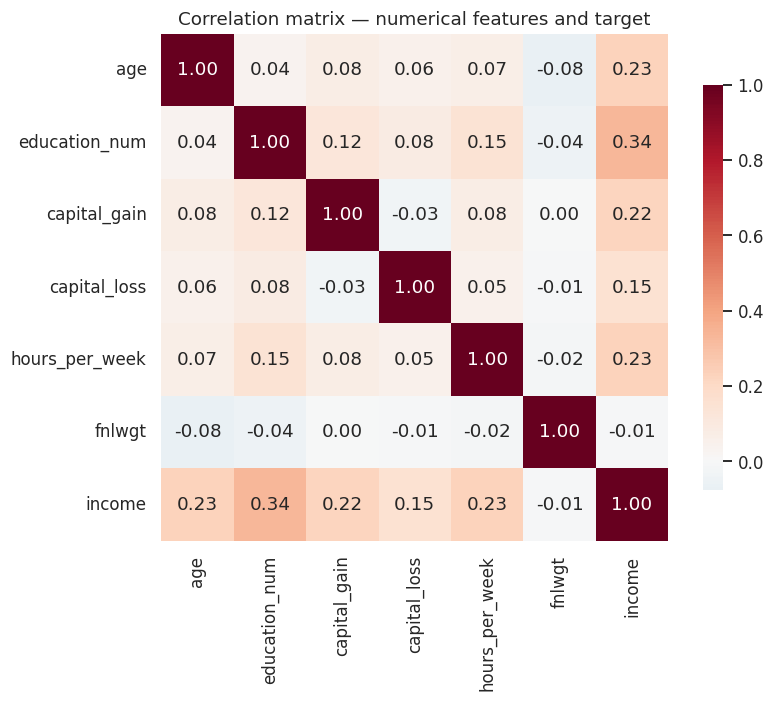

In [12]:
num_for_corr = ['age', 'education_num', 'capital_gain', 'capital_loss',
                'hours_per_week', 'fnlwgt', 'income']

plt.figure(figsize=(8, 6.5))
sns.heatmap(df[num_for_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix — numerical features and target')
plt.tight_layout()
plt.savefig(FIG / 'fig4_correlation.png', bbox_inches='tight')
plt.show()

## Correlation Analysis:

We compute the Pearson correlation coefficient between each numerical feature and the target, and between the features themselves. A correlation near +1 or -1 indicates a strong linear relationship whereas a value near 0 indicates little to no linear relation.

Observations:
- `education_num` is the strongest linear predictor at r = 0.34, followed by `age` at 0.23 and `hours_per_week` at 0.23.
- `capital_gain` comes in at only 0.22 despite the much larger effect shown earlier, for the reasons already given.
- `fnlwgt` sits at -0.01, confirming the decision to drop it.
- Inter feature correlations are uniformly low across the whole matrix.

Unlike a dataset dominated by several measurements of the same underlying quantity, there is no multicollinearity problem here. Regularisation is therefore not expected to deliver much benefit to the linear model, and no features are dropped on collinearity grounds.

In [13]:
miss_report = []
for col in ['workclass', 'occupation', 'native_country']:
    m = df[col].isna()
    miss_report.append({
        'feature': col,
        'n_missing': int(m.sum()),
        'pos_rate_missing': round(df.loc[m, 'income'].mean(), 3),
        'pos_rate_present': round(df.loc[~m, 'income'].mean(), 3),
    })

pd.DataFrame(miss_report)

,feature,n_missing,pos_rate_missing,pos_rate_present
0,workclass,1836,0.104,0.249
1,occupation,1843,0.104,0.249
2,native_country,583,0.250,0.241


### Missingness is itself a signal:

We compare the positive rate of records where each column is missing against records where it is present.

Observations:
- Records missing `workclass` or `occupation` have a positive rate of 0.104, which is less than half the 0.249 of records where those fields are present.
- The two columns are also missing together in almost every case, which is consistent with the missing records describing people who were not in work at the time of the survey.
- `native_country` shows no such effect, with rates of 0.250 against 0.241.

Not being in work is genuinely predictive of lower income, so this missingness is informative rather than random. Imputing these fields with the mode would actively destroy that signal by relabelling non workers as private sector employees, which is why our preprocessing encodes missing categoricals as an explicit `Unknown` category instead. `native_country` is handled the same way for consistency.

## Summary of EDA Findings:

The table below summarises the key findings from the EDA and the modelling decisions taken from them.

| Finding | Detail | Decision |
|---|---|---|
| Target is imbalanced | 24.1% positive, 75.9% negative | **Use ROC-AUC**, include a dummy baseline |
| 24 duplicate rows | 0.07% of data, plausible real profiles | **Keep**, no evidence they are errors |
| Missingness is informative | Positive rate 0.104 missing vs 0.249 present | **Encode as `Unknown`**, not mode impute |
| `education` is redundant | Each label maps to one `education_num` value | **Drop**, keep the ordinal encoding |
| `fnlwgt` is a survey artefact | r = -0.0095 with target, by design | **Drop**, describes sampling not the person |
| `capital_gain` is zero inflated | 91.7% zero, but 61.8% positive rate when non zero | **Motivates tree based models** |
| `age` is non monotonic | Rises to 35 to 55, then falls | **Motivates tree based models** |
| No multicollinearity | All inter feature correlations low | Regularisation not expected to help |
| `relationship` encodes sex | `Husband` is 13,192 of 13,193 male | Retain, but flag for the fairness audit |
| `native_country` has a long tail | 41 categories, many very rare | **One hot encode** with `min_frequency=10` |

---

# Preprocessing and Model Development:

Now that the EDA is complete we can move on to preprocessing and developing the models.

Each preprocessing step below is directly justified by a finding from the table above:

- **Drop `fnlwgt` and `education`:** For the reasons given in the EDA.
- **Median impute numerics:** Applied defensively, since no numerical column actually contains missing values, but included so the pipeline will not fail on unseen data.
- **Unknown category for missing categoricals:** Filled with the constant string `Unknown` rather than the mode, because missingness carries signal.
- **One hot encode categoricals:** Applied to all categorical features, since none of them has a meaningful ordering.
- **Pool rare categories:** The encoder is set with `min_frequency=10`, because `native_country` has 41 levels with a long tail and encoding every one produces columns that are almost entirely zero.
- **Handle unknown categories:** The encoder is set with `handle_unknown='ignore'` so a category appearing in the test file but absent from a given training fold does not cause a failure.
- **Standard scaler:** Applied to numerical features for the logistic regression only, so the L2 penalty applies evenly across features. Tree based models are invariant to monotonic rescaling, so we skip it for those.

The entire sequence is placed inside a scikit-learn `Pipeline` rather than being applied to the dataframe before splitting. This is the mechanism that prevents data leakage. When the pipeline is passed to `cross_validate`, the imputer, encoder and scaler are each fitted on the training portion of every fold and then only applied to the validation portion. Fitting a scaler on the full dataset before splitting would allow statistics from held out records to influence training, which inflates every score that follows and does so invisibly.

In [14]:
DROP_COLS = ['fnlwgt', 'education']

X_train = train_raw.drop(columns=['income'] + DROP_COLS)
y_train = train_raw['income']
X_test = test_raw.drop(columns=['income'] + DROP_COLS)
y_test = test_raw['income']

num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print('Numerical  :', num_cols)
print('Categorical:', cat_cols)


def make_preprocessor(scale: bool = False) -> ColumnTransformer:
    """Column transformer. Scaling is only needed for the linear model."""
    numeric_steps = [('impute', SimpleImputer(strategy='median'))]
    if scale:
        numeric_steps.append(('scale', StandardScaler()))

    return ColumnTransformer([
        ('num', Pipeline(numeric_steps), num_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10,
                                     sparse_output=False)),
        ]), cat_cols),
    ])


_pre = make_preprocessor(); _pre.fit(X_train)
print('\nFeatures after encoding:', _pre.transform(X_train).shape[1])

Numerical  : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']



Features after encoding: 91


## Model Development:

We now build four models, all evaluated using 5 fold stratified cross validation with ROC-AUC, PR-AUC, F1 and accuracy as metrics.

| Model | Algorithm | Rationale |
|---|---|---|
| Model 1 | Dummy Classifier (majority class) | Establishes the accuracy floor and demonstrates why accuracy is misleading |
| Model 2 | Logistic Regression | Interpretable linear baseline, tests how much of the signal is linearly separable |
| Model 3 | Random Forest | Captures the non linearity and feature interactions found in the EDA |
| Model 4 | Histogram Gradient Boosting | Sequential boosting, expected strongest given the non monotonic and step change relationships found in the EDA |

Model 1 is not filler. It is the control that makes every subsequent accuracy figure interpretable, and its F1 score is the clearest single piece of evidence that accuracy is the wrong headline metric here.

One caveat applies to this comparison and is worth stating up front rather than glossing over. Only Model 4 is subsequently tuned. Models 2 and 3 run at fixed and reasonable settings throughout, so what is being compared is a tuned boosting model against two sensible defaults rather than four equally optimised models. Given the roughly two point ROC-AUC gap and how little tuning moves the boosted model, it is very unlikely that symmetric tuning would change the ordering, but the comparison is not symmetric and a reader should know that.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ['roc_auc', 'average_precision', 'f1', 'accuracy']

models = {
    'Dummy (majority)': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', DummyClassifier(strategy='most_frequent'))]),
    'Logistic Regression': Pipeline([
        ('pre', make_preprocessor(scale=True)),
        ('clf', LogisticRegression(max_iter=2000, random_state=SEED))]),
    'Random Forest': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                       n_jobs=-1, random_state=SEED))]),
    'HistGradientBoosting': Pipeline([
        ('pre', make_preprocessor()),
        ('clf', HistGradientBoostingClassifier(random_state=SEED))]),
}

rows = []
for name, pipe in models.items():
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    row = {'model': name}
    for m in SCORING:
        row[m] = r['test_' + m].mean()
        row[m + '_std'] = r['test_' + m].std()
    rows.append(row)

cv_results = pd.DataFrame(rows).set_index('model')
cv_results.round(4)

,roc_auc,roc_auc_std,average_precision,average_precision_std,f1,f1_std,accuracy,accuracy_std
model,,,,,,,,
Dummy (majority),0.5000,0.0000,0.2408,0.0000,0.0000,0.0000,0.7592,0.0000
Logistic Regression,0.9066,0.0016,0.7663,0.0085,0.6626,0.0083,0.8519,0.0032
Random Forest,0.9179,0.0018,0.8040,0.0047,0.6792,0.0074,0.8639,0.0033
HistGradientBoosting,0.9284,0.0014,0.8293,0.0048,0.7133,0.0087,0.8728,0.0035


### Cross validation results:

Observations:
- Model 1 (dummy) reaches 75.9% accuracy with an F1 of exactly 0.000 and a ROC-AUC of exactly 0.500. It has identified not a single high earner.
- Model 2 (logistic regression) reaches a ROC-AUC of 0.9066 with a fold standard deviation of 0.0016.
- Model 3 (random forest) reaches 0.9179, standard deviation 0.0018.
- Model 4 (gradient boosting) reaches 0.9284, standard deviation 0.0014, and is the strongest on every metric as well as the most stable across folds.

The dummy result is the whole argument about metric choice in one row. Any model reporting "85% accuracy" on this dataset is only nine points above a model that does nothing, which is precisely why we rejected accuracy as the primary metric.

The roughly two point ROC-AUC gap between logistic regression and gradient boosting is the measurable value of being able to represent non linearity on this data, and it lines up with what the EDA predicted. The non monotonic age relationship and the step change in `capital_gain` are exactly the structures a linear model cannot capture without manual feature engineering.

For external context, a published benchmark on this dataset reports ROC-AUC values of 0.907 for logistic regression, 0.903 for random forest and 0.927 for XGBoost. Our results sit at parity with those figures rather than above or below them.

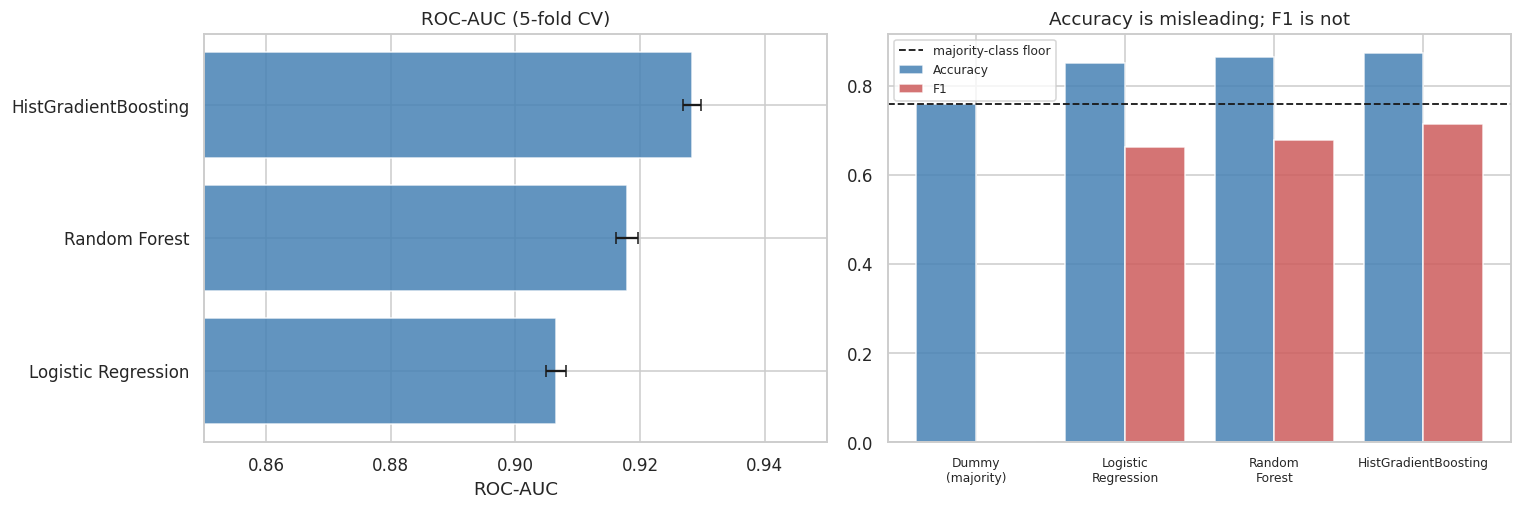

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

plot_df = cv_results.drop(index='Dummy (majority)')
axes[0].barh(plot_df.index, plot_df['roc_auc'], xerr=plot_df['roc_auc_std'],
             color='steelblue', alpha=0.85, capsize=4)
axes[0].set_xlim(0.85, 0.95)
axes[0].set_xlabel('ROC-AUC'); axes[0].set_title('ROC-AUC (5-fold CV)')

x = np.arange(len(cv_results))
axes[1].bar(x - 0.2, cv_results['accuracy'], 0.4, label='Accuracy', color='steelblue', alpha=0.85)
axes[1].bar(x + 0.2, cv_results['f1'], 0.4, label='F1', color='indianred', alpha=0.85)
axes[1].axhline(1 - y_train.mean(), color='k', ls='--', lw=1.2, label='majority-class floor')
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' ', '\n') for m in cv_results.index], fontsize=8)
axes[1].set_title('Accuracy is misleading; F1 is not')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'fig5_model_comparison.png', bbox_inches='tight')
plt.show()

The right hand panel above is the argument about metric choice in a single picture.

Observations:
- The dummy classifier's accuracy bar very nearly touches the dashed majority class floor while its F1 bar is invisible at zero.
- Across the four models accuracy moves from 0.76 to 0.87, an eleven point range which makes a model that identifies nobody look merely mediocre rather than useless.
- Over the same four models F1 moves from 0.00 to 0.71, which reflects what actually changed.

We select Model 4 (HistGradientBoosting) to carry forward.

## Hyperparameter Tuning:

We run a grid search over 12 configurations using the same 5 fold stratified cross validation, scored on ROC-AUC. The parameters searched are `learning_rate`, `max_leaf_nodes` and `min_samples_leaf`, with `l2_regularization` fixed at 1.0. These control the bias variance trade off, with the learning rate and leaf count setting model capacity and the minimum leaf size constraining it.

In [17]:
param_grid = {
    'clf__learning_rate':    [0.05, 0.1],
    'clf__max_leaf_nodes':   [15, 31, 63],
    'clf__min_samples_leaf': [20, 50],
}

tuned_base = Pipeline([
    ('pre', make_preprocessor()),
    ('clf', HistGradientBoostingClassifier(random_state=SEED, l2_regularization=1.0)),
])

gs = GridSearchCV(tuned_base, param_grid, scoring='roc_auc', cv=cv)
gs.fit(X_train, y_train)

print('Best parameters:')
for k, v in gs.best_params_.items():
    print(f'  {k:28s} {v}')

res = pd.DataFrame(gs.cv_results_)
print(f'\nBest CV ROC-AUC:    {gs.best_score_:.4f}')
print(f'Untuned CV ROC-AUC: {cv_results.loc["HistGradientBoosting", "roc_auc"]:.4f}')
print(f'Worst of 12 configs: {res.mean_test_score.min():.4f}')
print(f'Spread across grid:  {res.mean_test_score.max() - res.mean_test_score.min():.4f}')

best_model = gs.best_estimator_

Best parameters:
  clf__learning_rate           0.1
  clf__max_leaf_nodes          31
  clf__min_samples_leaf        50

Best CV ROC-AUC:    0.9289
Untuned CV ROC-AUC: 0.9284
Worst of 12 configs: 0.9234
Spread across grid:  0.0054


Observations:
- The best configuration is a learning rate of 0.1, 31 leaf nodes and a minimum of 50 samples per leaf, scoring a cross validated ROC-AUC of 0.9289 against the untuned 0.9284.
- This is an improvement of 0.0005, which is roughly a third of the model's own fold to fold standard deviation of 0.0014.
- The worst of the 12 configurations scores 0.9234, giving a total spread across the entire grid of only 0.0054.

Tuning therefore did essentially nothing on this dataset, and we report that as a result rather than hiding it. The model is insensitive to these hyperparameters here and the defaults were already close to optimal.

The important finding is not which configuration won, but that the whole grid sits within half a point of itself. That tells us the remaining error is not a model capacity problem, so no amount of further grid searching will recover it, and the limiting factor must be the information content of the 12 available features.

## Threshold Selection:

Everything to this point evaluates the model's ranking of records. Converting that ranking into actual decisions requires choosing a threshold, and 0.5 is a default value rather than a considered decision. With a 24% positive rate, 0.5 sits close to the threshold that maximises accuracy, which is the metric we already rejected as unsuitable.

We select thresholds using out of fold predictions generated on the training set by `cross_val_predict`, so the test set remains untouched. Two candidate operating points are derived.

The first is the F1 optimal threshold, which is the balanced choice when precision and recall are considered equally important.

In [18]:
oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv,
                              method='predict_proba')[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)

best_idx = int(np.nanargmax(f1_scores[:-1]))
thr_f1 = float(thresholds[best_idx])

print(f'Default 0.50       -> F1 {f1_score(y_train, (oof_proba >= 0.5).astype(int)):.4f}')
print(f'F1-optimal {thr_f1:.3f}  -> F1 {f1_scores[best_idx]:.4f} '
      f'(precision {precision[best_idx]:.4f}, recall {recall[best_idx]:.4f})')

Default 0.50       -> F1 0.7151
F1-optimal 0.389  -> F1 0.7331 (precision 0.7105, recall 0.7572)


The second candidate operating point is the cost optimal threshold, derived by assuming a false negative is three times as costly as a false positive and minimising the resulting total cost.

The reasoning behind the assumption is that if a model of this kind were used to route people toward a benefits programme or a financial product, wrongly excluding an eligible person is worse than the cost of reviewing an ineligible one.

In [19]:
COST_FN, COST_FP = 3, 1

grid_t = np.linspace(0.05, 0.95, 181)
costs = []
for t in grid_t:
    tn, fp, fn, tp = confusion_matrix(y_train, (oof_proba >= t).astype(int)).ravel()
    costs.append(COST_FP * fp + COST_FN * fn)
costs = np.array(costs)
thr_cost = float(grid_t[costs.argmin()])

print(f'Cost-optimal threshold (FN = {COST_FN}x FP): {thr_cost:.3f}')
print(f'Cost there: {costs.min():,.0f}   |   Cost at 0.50: {costs[np.abs(grid_t - 0.5).argmin()]:,.0f}')

Cost-optimal threshold (FN = 3x FP): 0.225
Cost there: 7,514   |   Cost at 0.50: 9,448


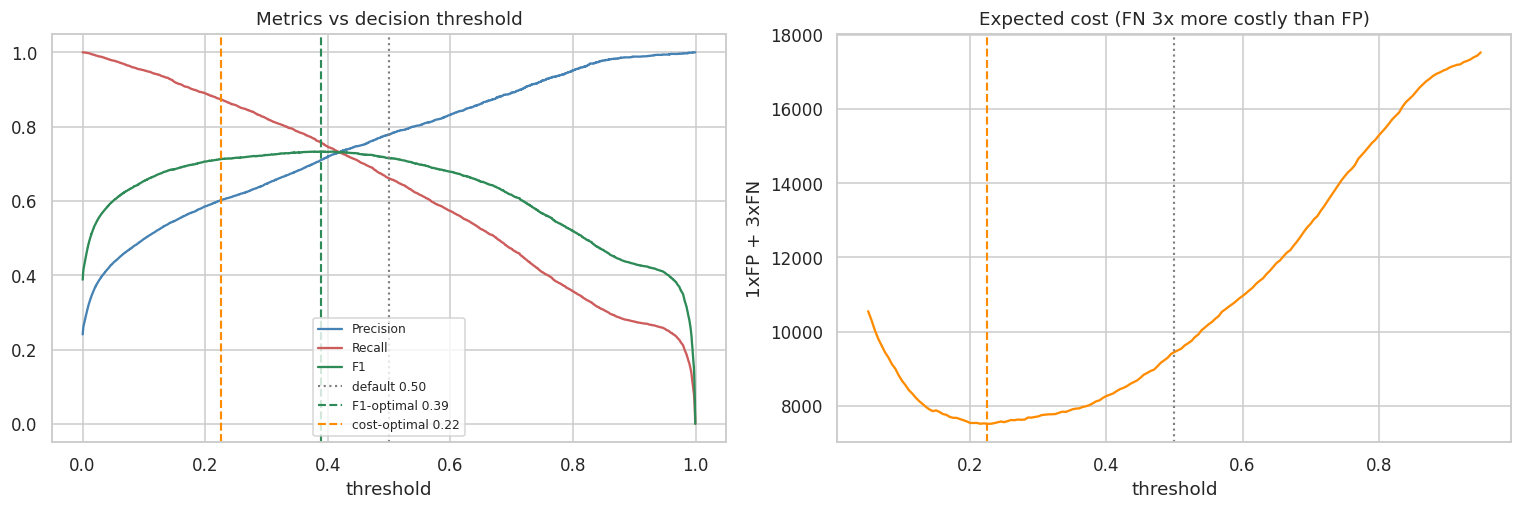

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(thresholds, precision[:-1], label='Precision', color='steelblue')
axes[0].plot(thresholds, recall[:-1], label='Recall', color='indianred')
axes[0].plot(thresholds, f1_scores[:-1], label='F1', color='seagreen')
axes[0].axvline(0.5, color='grey', ls=':', lw=1.4, label='default 0.50')
axes[0].axvline(thr_f1, color='seagreen', ls='--', lw=1.4, label=f'F1-optimal {thr_f1:.2f}')
axes[0].axvline(thr_cost, color='darkorange', ls='--', lw=1.4, label=f'cost-optimal {thr_cost:.2f}')
axes[0].set_xlabel('threshold'); axes[0].set_title('Metrics vs decision threshold')
axes[0].legend(fontsize=8)

axes[1].plot(grid_t, costs, color='darkorange')
axes[1].axvline(thr_cost, color='darkorange', ls='--', lw=1.4)
axes[1].axvline(0.5, color='grey', ls=':', lw=1.4)
axes[1].set_xlabel('threshold'); axes[1].set_ylabel(f'{COST_FP}xFP + {COST_FN}xFN')
axes[1].set_title('Expected cost (FN 3x more costly than FP)')

plt.tight_layout()
plt.savefig(FIG / 'fig6_threshold.png', bbox_inches='tight')
plt.show()

Observations:
- The left panel shows that the precision and recall trade off is steep in the region around the default of 0.5.
- The right panel shows that the cost curve is asymmetric and clearly minimised well below 0.5, at 0.225. Under the stated assumption the default threshold is a materially worse decision rule rather than a neutral starting point.
- The cost curve is fairly flat between roughly 0.17 and 0.30, which means the chosen value is not fragile and small errors in the cost assumption would not greatly change the outcome.

It should be stressed that the 3:1 ratio is an assumption that we stated and then applied, not a quantity measured from the data. A different ratio produces a different threshold, and the threshold should never be quoted without the assumption that generated it.

# Final Evaluation on the Test Set:

We refit the tuned model on the complete training file and evaluate it once on the 16,281 held out test records.

All three thresholds are reported rather than only the most flattering one, because selecting a single row from this table and presenting it as the result would misrepresent the trade off being made.

In [21]:
best_model.fit(X_train, y_train)
test_proba = best_model.predict_proba(X_test)[:, 1]

print(f'Test ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}')
print(f'Test PR-AUC:  {average_precision_score(y_test, test_proba):.4f}')
print(f'(CV ROC-AUC was {gs.best_score_:.4f})')

rows = []
for label, t in [('Default 0.50', 0.5),
                 (f'F1-optimal {thr_f1:.2f}', thr_f1),
                 (f'Cost-optimal {thr_cost:.3f}', thr_cost)]:
    pred = (test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({'threshold': label,
                 'accuracy': accuracy_score(y_test, pred),
                 'precision': precision_score(y_test, pred),
                 'recall': recall_score(y_test, pred),
                 'f1': f1_score(y_test, pred), 'FP': fp, 'FN': fn})

pd.DataFrame(rows).set_index('threshold').round(4)

Test ROC-AUC: 0.9273
Test PR-AUC:  0.8255
(CV ROC-AUC was 0.9289)


,accuracy,precision,recall,f1,FP,FN
threshold,,,,,,
Default 0.50,0.8732,0.7744,0.6534,0.7088,732,1333
F1-optimal 0.39,0.8648,0.7004,0.7470,0.7229,1229,973
Cost-optimal 0.225,0.8281,0.5923,0.8747,0.7063,2316,482


### Bootstrap confidence intervals:

A single test set gives a point estimate, not a fact. We resample the 16,281 test records with replacement 1,000 times to get an interval for each metric, and more importantly a way of telling whether the comparisons later in this notebook reflect real differences or just noise.

In [22]:
rng = np.random.default_rng(SEED)
B = 1000
n = len(y_test)
yt = y_test.values
sex_te = X_test['sex'].values
pred_cost = (test_proba >= thr_cost).astype(int)


def tpr_of(y_arr, pred_arr):
    tn, fp, fn, tp = confusion_matrix(y_arr, pred_arr, labels=[0, 1]).ravel()
    return tp / (tp + fn) if (tp + fn) else np.nan


boot = {k: [] for k in ['ROC-AUC', 'PR-AUC', 'F1', 'accuracy', 'recall', 'TPR gap (M-F)']}
for _ in range(B):
    i = rng.integers(0, n, n)
    boot['ROC-AUC'].append(roc_auc_score(yt[i], test_proba[i]))
    boot['PR-AUC'].append(average_precision_score(yt[i], test_proba[i]))
    boot['F1'].append(f1_score(yt[i], pred_cost[i]))
    boot['accuracy'].append(accuracy_score(yt[i], pred_cost[i]))
    boot['recall'].append(recall_score(yt[i], pred_cost[i]))
    m, f = sex_te[i] == 'Male', sex_te[i] == 'Female'
    boot['TPR gap (M-F)'].append(tpr_of(yt[i][m], pred_cost[i][m]) -
                                 tpr_of(yt[i][f], pred_cost[i][f]))

ci_tbl = pd.DataFrame([
    {'metric': k, 'estimate': np.mean(v),
     'ci_low': np.percentile(v, 2.5), 'ci_high': np.percentile(v, 97.5),
     'half_width': (np.percentile(v, 97.5) - np.percentile(v, 2.5)) / 2}
    for k, v in boot.items()
]).set_index('metric')

ci_tbl.round(4)

,estimate,ci_low,ci_high,half_width
metric,,,,
ROC-AUC,0.9273,0.9230,0.9314,0.0042
PR-AUC,0.8254,0.8154,0.8360,0.0103
F1,0.7062,0.6962,0.7173,0.0106
accuracy,0.8282,0.8226,0.8340,0.0057
recall,0.8746,0.8644,0.8847,0.0101
TPR gap (M-F),0.1188,0.0850,0.1541,0.0345


### Test results:

Observations:
- Test ROC-AUC is 0.9273 with a 95% confidence interval of [0.9230, 0.9314], against a cross validated 0.9289. The two agree closely, which is the practical evidence that our pipeline is not leaking.
- The half width on ROC-AUC is 0.0042. This is the number that governs everything that follows, because any later comparison differing by less than roughly 0.004 ROC-AUC is not a difference this test set is capable of resolving.
- Moving from the default threshold of 0.50 to the cost optimal 0.225 raises recall from 0.653 to 0.875, which means finding 851 more of the 3,846 true high earners in the test set.
- The price is that false positives rise from 732 to 2,316 and headline accuracy falls from 0.873 to 0.828.

Whether that is a good trade cannot be answered from the data. It follows entirely from the 3:1 cost assumption, which we chose rather than measured. The honest framing is that the model supplies a calibrated ranking and the threshold is a policy decision belonging to whoever deploys it.

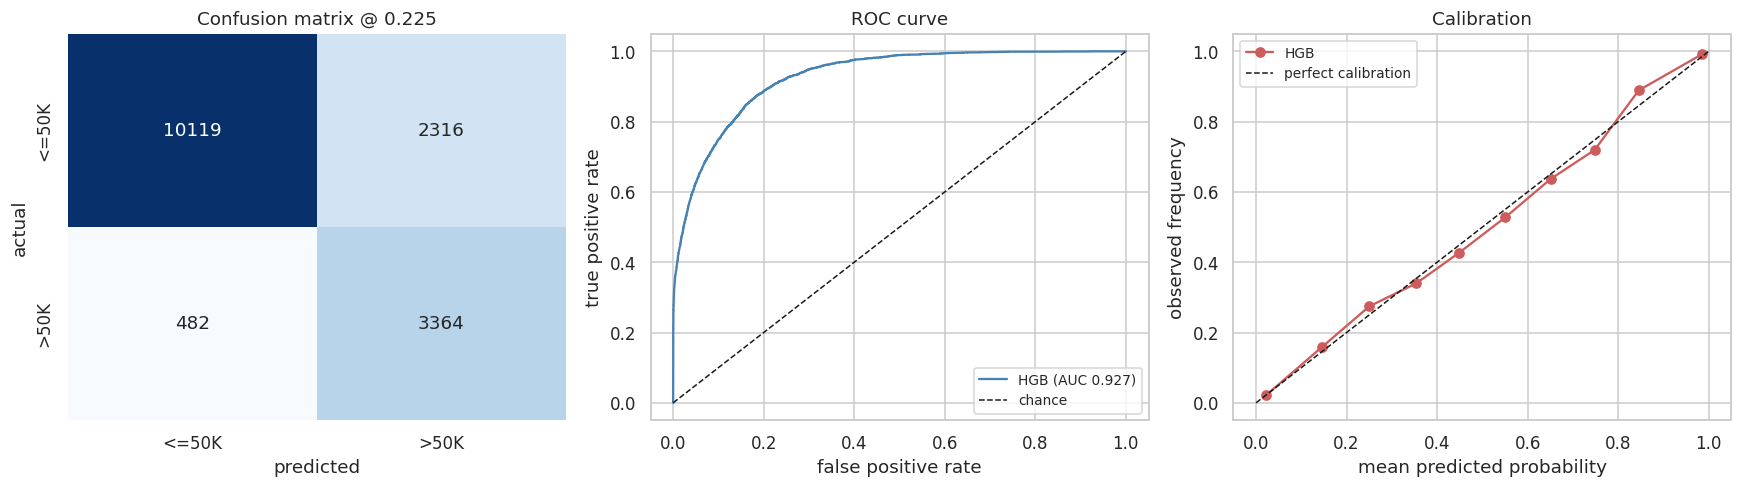

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

cm = confusion_matrix(y_test, pred_cost)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('actual')
axes[0].set_title(f'Confusion matrix @ {thr_cost:.3f}')

fpr, tpr_c, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr_c, color='steelblue',
             label=f'HGB (AUC {roc_auc_score(y_test, test_proba):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='chance')
axes[1].set_xlabel('false positive rate'); axes[1].set_ylabel('true positive rate')
axes[1].set_title('ROC curve'); axes[1].legend(fontsize=9)

frac_pos, mean_pred = calibration_curve(y_test, test_proba, n_bins=10)
axes[2].plot(mean_pred, frac_pos, 'o-', color='indianred', label='HGB')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='perfect calibration')
axes[2].set_xlabel('mean predicted probability'); axes[2].set_ylabel('observed frequency')
axes[2].set_title('Calibration'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG / 'fig7_test_evaluation.png', bbox_inches='tight')
plt.show()

The calibration plot on the right matters more than it might first appear.

Observations:
- The points track the diagonal closely across the whole range, which means that when the model outputs a score of 0.25, roughly a quarter of the records receiving that score really are high earners.
- The ROC curve in the centre shows the model operating well above chance across the full range of thresholds.

Calibration is what makes our threshold analysis legitimate rather than decorative. Choosing an operating point by minimising expected cost only means something if the predicted probabilities correspond to real frequencies. On a badly calibrated model the cost curve would be minimising a quantity that does not correspond to anything, and the resulting threshold would be arbitrary. Gradient boosting happens to be well calibrated on this dataset without any post hoc correction, so no calibration step was required, but we checked rather than assumed.

## Feature Importance:

Permutation importance measures how far test ROC-AUC falls when a single column is randomly shuffled. We use it in preference to the tree's built in impurity based importance because it is measured on held out data and is not biased toward high cardinality features.

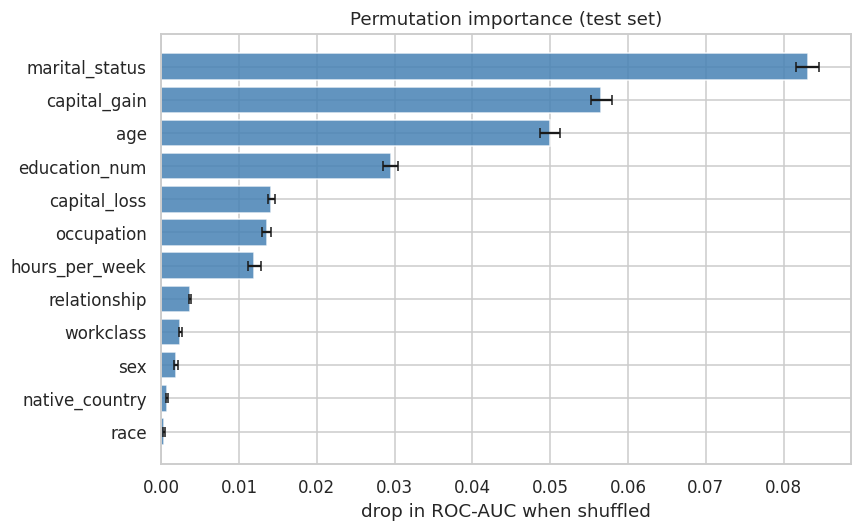

,feature,importance,std
3,marital_status,0.0831,0.0014
8,capital_gain,0.0566,0.0014
0,age,0.0500,0.0013
2,education_num,0.0295,0.0010
9,capital_loss,0.0141,0.0004
4,occupation,0.0135,0.0006
10,hours_per_week,0.0120,0.0008
5,relationship,0.0037,0.0001
1,workclass,0.0025,0.0002
7,sex,0.0019,0.0002


In [24]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=5,
                              random_state=SEED, scoring='roc_auc')

imp = (pd.DataFrame({'feature': X_test.columns,
                     'importance': perm.importances_mean,
                     'std': perm.importances_std})
         .sort_values('importance', ascending=False))

plt.figure(figsize=(8, 5))
plt.barh(imp['feature'][::-1], imp['importance'][::-1],
         xerr=imp['std'][::-1], color='steelblue', alpha=0.85, capsize=3)
plt.xlabel('drop in ROC-AUC when shuffled')
plt.title('Permutation importance (test set)')
plt.tight_layout()
plt.savefig(FIG / 'fig8_importance.png', bbox_inches='tight')
plt.show()

imp.round(4)

Observations:
- `marital_status` is the most important feature by this measure, ahead of `capital_gain`, `age` and `education_num`. This is consistent with the EDA findings.
- Both `sex` and `race` sit at the bottom of the chart with permutation importance values close to zero, meaning that shuffling either of them barely moves the model's ability to discriminate.

The tempting conclusion from that second point is that the model therefore does not depend on `sex` and `race` in any meaningful way. The next section tests that conclusion directly and finds it to be false.

# Fairness Audit:

We evaluate the model separately on subgroups defined by `sex` and `race`, at the cost optimal threshold. Three quantities are reported for each group:

- **Selection rate:** the proportion of the group predicted positive.
- **True positive rate (TPR):** the proportion of genuinely high income people in the group that the model finds.
- **False positive rate (FPR):** the proportion of genuinely lower income people in the group that the model wrongly flags.

Equal selection rates across groups is the criterion known as demographic parity, and equal true positive rates is the criterion known as equal opportunity. The two are mathematically incompatible whenever base rates differ between groups, which they do substantially here, so the purpose of this section is to make the disparity visible and legible rather than to declare one criterion the winner.

Subgroups with fewer than 300 test records are excluded, which removes `Amer-Indian-Eskimo` and `Other`, because error rates estimated on samples that small are not trustworthy enough to report. This exclusion is itself discussed in the ethics section.

In [25]:
audit = X_test.copy()
audit['y_true'] = y_test.values
audit['y_pred'] = pred_cost


def slice_metrics(frame, by, min_n=300):
    out = []
    for group, sub in frame.groupby(by):
        if len(sub) < min_n:
            continue
        tn, fp, fn, tp = confusion_matrix(sub.y_true, sub.y_pred, labels=[0, 1]).ravel()
        out.append({'group': f'{by}={group}', 'n': len(sub),
                    'base_rate': sub.y_true.mean(),
                    'selection_rate': sub.y_pred.mean(),
                    'TPR': tp / (tp + fn), 'FPR': fp / (fp + tn),
                    'precision': precision_score(sub.y_true, sub.y_pred, zero_division=0)})
    return pd.DataFrame(out)


audit_tbl = pd.concat([slice_metrics(audit, 'sex'), slice_metrics(audit, 'race')],
                      ignore_index=True)
audit_tbl.round(3)

,group,n,base_rate,selection_rate,TPR,FPR,precision
0,sex=Female,5421,0.109,0.143,0.775,0.066,0.589
1,sex=Male,10860,0.300,0.452,0.893,0.263,0.593
2,race=Asian-Pac-Islander,480,0.277,0.402,0.880,0.219,0.606
3,race=Black,1561,0.115,0.161,0.827,0.075,0.590
4,race=White,13946,0.250,0.371,0.877,0.202,0.592


### Subgroup results:

Observations:
- Men are selected at a rate of 45.2% and women at 14.3%, a gap of 30.9 percentage points.
- Part of this reflects a real difference in base rates, since 30.0% of men in this sample earn above \$50K against 10.9% of women.
- True positive rate is 0.893 for men against 0.775 for women. The model misses more than one in five genuinely high earning women against roughly one in ten high earning men.
- By race, the White subgroup has a TPR of 0.877 and the Black subgroup 0.827, with precision almost identical at 0.592 and 0.590.

Base rates do not explain the true positive rate gap, and this is the finding that matters. TPR is computed only among people who genuinely do earn above \$50K, so a difference of 11.8 percentage points means the model is worse at recognising high earning women than high earning men within the group where the correct answer is identical for both.

The bootstrap puts that gap at 0.1188 with a 95% confidence interval of [0.0850, 0.1541]. The interval excludes zero comfortably, so this is a real and measurable disparity rather than an artefact of a particular test sample.

We plot the base rate, selection rate and true positive rate side by side for each subgroup.

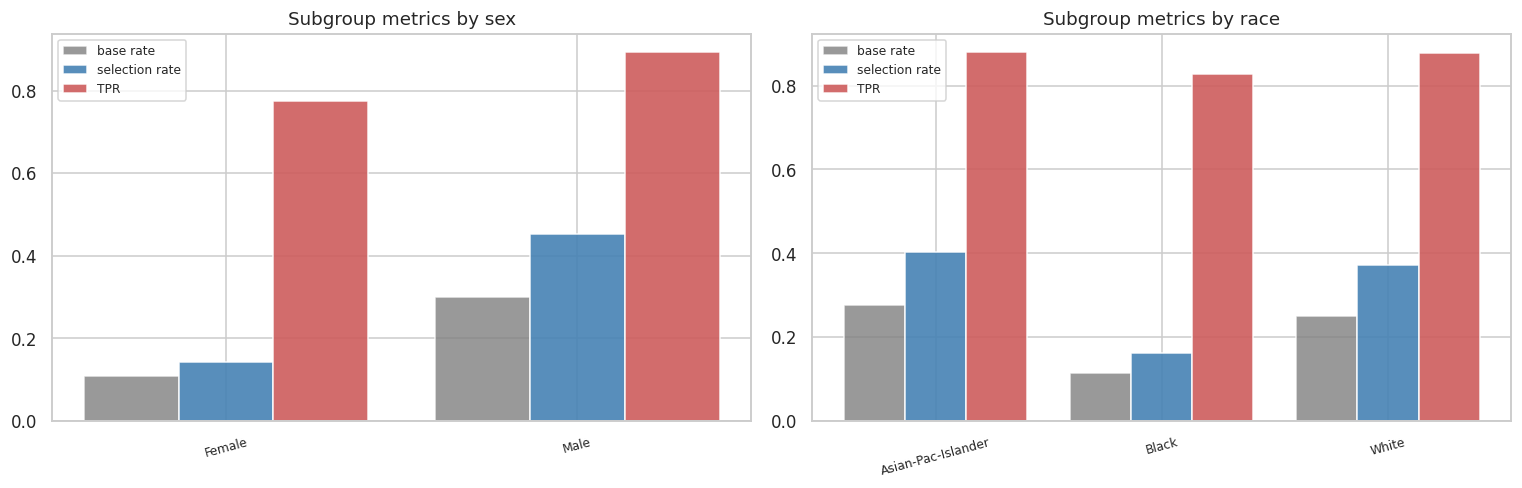

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

for ax, (by, tbl) in zip(axes, [('sex', slice_metrics(audit, 'sex')),
                                ('race', slice_metrics(audit, 'race'))]):
    x = np.arange(len(tbl))
    ax.bar(x - 0.27, tbl['base_rate'],      0.27, label='base rate',      color='grey',      alpha=0.8)
    ax.bar(x,        tbl['selection_rate'], 0.27, label='selection rate', color='steelblue', alpha=0.9)
    ax.bar(x + 0.27, tbl['TPR'],            0.27, label='TPR',            color='indianred', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([g.split('=')[1] for g in tbl['group']], fontsize=8, rotation=15)
    ax.set_title(f'Subgroup metrics by {by}'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'fig9_fairness.png', bbox_inches='tight')
plt.show()

### Attempt 1: removing the protected attributes

The obvious remedy is to delete `sex` and `race` from the feature set, an approach usually called fairness through unawareness. The permutation importance results suggested this should be close to free, since both features scored near zero.

We compare three feature sets. The first is the full set, the second removes the two protected attributes, and the third also removes `relationship` and `marital_status`, which the EDA showed encode sex almost perfectly.

Each variant is compared against the full model using a paired bootstrap, in which the same resampled test set is used to evaluate both models and the difference is computed within each resample. This controls for the fact that both models are being scored on identical records and gives much tighter intervals than comparing two independent confidence intervals would.

In [27]:
def build_variant(drop_cols):
    Xtr = X_train.drop(columns=drop_cols)
    Xte = X_test.drop(columns=drop_cols)
    nc = Xtr.select_dtypes(include='number').columns.tolist()
    cc = [c for c in Xtr.columns if c not in nc]
    pipe = Pipeline([
        ('pre', ColumnTransformer([
            ('num', SimpleImputer(strategy='median'), nc),
            ('cat', Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10,
                                         sparse_output=False))]), cc)])),
        ('clf', HistGradientBoostingClassifier(
            random_state=SEED, l2_regularization=1.0,
            learning_rate=gs.best_params_['clf__learning_rate'],
            max_leaf_nodes=gs.best_params_['clf__max_leaf_nodes'],
            min_samples_leaf=gs.best_params_['clf__min_samples_leaf'])),
    ])
    pipe.fit(Xtr, y_train)
    return pipe.predict_proba(Xte)[:, 1]


def sex_gap(y_arr, pred_arr, sex_arr):
    return (tpr_of(y_arr[sex_arr == 'Male'], pred_arr[sex_arr == 'Male']) -
            tpr_of(y_arr[sex_arr == 'Female'], pred_arr[sex_arr == 'Female']))


variants = {
    'All features': [],
    'Drop sex + race': ['sex', 'race'],
    'Drop sex, race + proxies': ['sex', 'race', 'relationship', 'marital_status'],
}
probas = {k: build_variant(v) for k, v in variants.items()}

rows = []
for label, pr in probas.items():
    pd_ = (pr >= thr_cost).astype(int)
    m, f = sex_te == 'Male', sex_te == 'Female'
    rows.append({'feature set': label, 'ROC-AUC': roc_auc_score(y_test, pr),
                 'TPR (F)': tpr_of(yt[f], pd_[f]), 'TPR (M)': tpr_of(yt[m], pd_[m]),
                 'TPR gap': sex_gap(yt, pd_, sex_te),
                 'sel. rate gap': pd_[m].mean() - pd_[f].mean()})

pd.DataFrame(rows).set_index('feature set').round(4)

,ROC-AUC,TPR (F),TPR (M),TPR gap,sel. rate gap
feature set,,,,,
All features,0.9273,0.7746,0.8928,0.1182,0.3084
Drop sex + race,0.9273,0.8017,0.8848,0.0831,0.2867
"Drop sex, race + proxies",0.8858,0.7797,0.8259,0.0462,0.1691


We now run the paired bootstrap to tell whether the differences above are real or just noise.

In [28]:
# Paired bootstrap: cost in AUC, and reduction in TPR gap, vs the full model
base_p = probas['All features']
base_pred = (base_p >= thr_cost).astype(int)
rng = np.random.default_rng(SEED)

paired = []
for label in ['Drop sex + race', 'Drop sex, race + proxies']:
    pr = probas[label]
    pd_ = (pr >= thr_cost).astype(int)
    d_auc, d_gap = [], []
    for _ in range(400):
        i = rng.integers(0, n, n)
        d_auc.append(roc_auc_score(yt[i], base_p[i]) - roc_auc_score(yt[i], pr[i]))
        d_gap.append(sex_gap(yt[i], base_pred[i], sex_te[i]) -
                     sex_gap(yt[i], pd_[i], sex_te[i]))
    paired.append({'feature set': label,
                   'AUC cost': np.mean(d_auc),
                   'AUC cost CI': f'[{np.percentile(d_auc, 2.5):.4f}, {np.percentile(d_auc, 97.5):.4f}]',
                   'TPR-gap reduction': np.mean(d_gap),
                   'gap CI': f'[{np.percentile(d_gap, 2.5):.4f}, {np.percentile(d_gap, 97.5):.4f}]'})

pd.DataFrame(paired).set_index('feature set').round(4)

,AUC cost,AUC cost CI,TPR-gap reduction,gap CI
feature set,,,,
Drop sex + race,0.0000,"[-0.0007, 0.0006]",0.0352,"[0.0211, 0.0491]"
"Drop sex, race + proxies",0.0415,"[0.0382, 0.0455]",0.0710,"[0.0309, 0.1158]"


### Unawareness is nearly free, and nearly useless

Observations:
- Removing `sex` and `race` costs nothing this test set can measure. The paired difference in ROC-AUC is 0.0000 with an interval of [-0.0007, 0.0006], straddling zero. This is a far stronger statement than observing that two rounded numbers look similar.
- What it buys is small. The true positive rate gap falls by 0.035, leaving 0.083 of the original 0.118 intact, so about 70% of the disparity survives the deletion of the attributes it is defined over.
- Removing the proxies as well reduces the gap further, by 0.071 with an interval of [0.031, 0.116], but costs 0.0415 of ROC-AUC with an interval of [0.0382, 0.0455]. That cost is an order of magnitude larger than the resolution of this test set, so unlike the previous comparison it is unambiguously real, and a residual gap of 0.046 still remains.

The reason unawareness fails is the proxy structure we identified in the EDA. The model reconstructs sex from `relationship`, where `Husband` is 13,192 of 13,193 male, and from `marital_status`. Deleting the label does not delete the information.

A note on an earlier version of this analysis is worth including here. When this experiment was first run on an arbitrary random 80/20 split rather than the canonical one, and without the paired bootstrap, it appeared to show the true positive rate gap widening when the proxies were removed, which made for a tidier narrative about unawareness backfiring. That finding did not survive either the canonical split or the paired bootstrap, and it was noise. We record it here rather than quietly deleting it because the methodological point is more valuable than the tidy narrative. Single split comparisons below the resolution of the test set will produce confident sounding conclusions that are not there, and the only defence is to measure the resolution first.

### Attempt 2: equal opportunity post processing

Deleting features is a blunt instrument, since it degrades the model for everybody in the hope of narrowing a gap between two groups. A better targeted approach leaves the model untouched and changes the decision rule instead, choosing a separate threshold for each group so that the true positive rates are equalised.

We derive thresholds from the out of fold training predictions, selecting for each group the threshold achieving a given target true positive rate, and then apply them unchanged to the test set. Sweeping the target traces out a frontier of achievable operating points.

In [29]:
sex_tr = X_train['sex'].values
y_tr_arr = y_train.values


def threshold_for_tpr(scores, labels, target):
    """Lowest threshold achieving at least `target` TPR on this group's positives."""
    pos = np.sort(scores[labels == 1])[::-1]
    k = min(max(int(np.ceil(target * len(pos))) - 1, 0), len(pos) - 1)
    return float(pos[k])


frontier = []
for target in np.arange(0.60, 0.9751, 0.025):
    thr_g = {g: threshold_for_tpr(oof_proba[sex_tr == g], y_tr_arr[sex_tr == g], target)
             for g in ['Female', 'Male']}
    pred_g = np.zeros(n, int)
    for g, t in thr_g.items():
        m = sex_te == g
        pred_g[m] = (test_proba[m] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, pred_g).ravel()
    frontier.append({'target TPR': round(target, 3),
                     'thr (F)': round(thr_g['Female'], 3), 'thr (M)': round(thr_g['Male'], 3),
                     'accuracy': accuracy_score(yt, pred_g), 'recall': recall_score(yt, pred_g),
                     'precision': precision_score(yt, pred_g), 'cost': fp + 3 * fn,
                     'TPR gap': sex_gap(yt, pred_g, sex_te)})

frontier_df = pd.DataFrame(frontier)

# Global-threshold baseline, and the matched-recall point on the frontier
tn, fp, fn, tp = confusion_matrix(yt, pred_cost).ravel()
global_recall = recall_score(yt, pred_cost)
j = (frontier_df['recall'] - global_recall).abs().idxmin()

print(f'Global threshold {thr_cost:.3f}:  accuracy {accuracy_score(yt, pred_cost):.4f}  '
      f'recall {global_recall:.4f}  cost {fp + 3 * fn}  TPR gap {sex_gap(yt, pred_cost, sex_te):.4f}')
print()
print('Matched-recall equal-opportunity point:')
print(frontier_df.loc[j].to_string())

Global threshold 0.225:  accuracy 0.8281  recall 0.8747  cost 3762  TPR gap 0.1182

Matched-recall equal-opportunity point:
target TPR       0.875000
thr (F)          0.103000
thr (M)          0.251000
accuracy         0.820158
recall           0.870255
precision        0.579467
cost          3926.000000
TPR gap          0.010912


We bootstrap the residual gap and the accuracy cost of the group specific thresholds, to check whether the remaining disparity is distinguishable from zero.

In [30]:
eo_thr = {'Female': frontier_df.loc[j, 'thr (F)'], 'Male': frontier_df.loc[j, 'thr (M)']}
pred_eo = np.zeros(n, int)
for g, t in eo_thr.items():
    m = sex_te == g
    pred_eo[m] = (test_proba[m] >= t).astype(int)

rng = np.random.default_rng(SEED)
resid_gap, acc_cost = [], []
for _ in range(600):
    i = rng.integers(0, n, n)
    resid_gap.append(sex_gap(yt[i], pred_eo[i], sex_te[i]))
    acc_cost.append(accuracy_score(yt[i], pred_cost[i]) - accuracy_score(yt[i], pred_eo[i]))

print(f'Residual TPR gap: {np.mean(resid_gap):.4f}  '
      f'95% CI [{np.percentile(resid_gap, 2.5):.4f}, {np.percentile(resid_gap, 97.5):.4f}]')
print(f'Accuracy cost:    {np.mean(acc_cost):.4f}  '
      f'95% CI [{np.percentile(acc_cost, 2.5):.4f}, {np.percentile(acc_cost, 97.5):.4f}]')

Residual TPR gap: 0.0115  95% CI [-0.0198, 0.0415]
Accuracy cost:    0.0079  95% CI [0.0050, 0.0108]


Finally we plot the frontier against the single global threshold, to show what equalising the true positive rate actually costs.

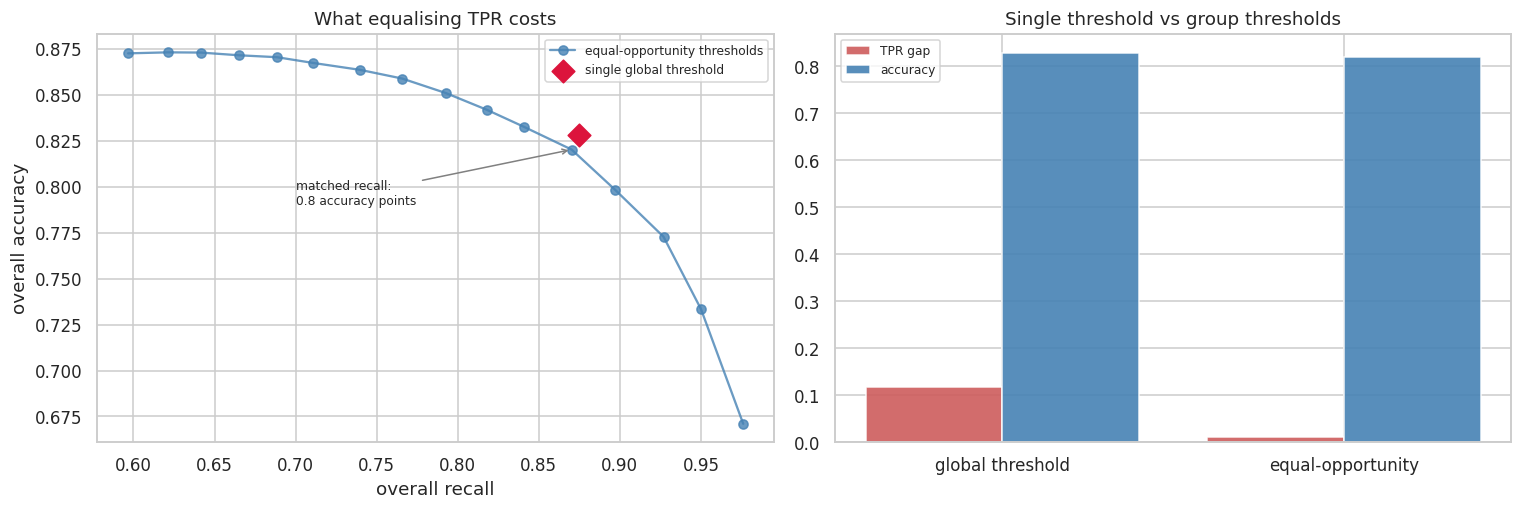

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(frontier_df['recall'], frontier_df['accuracy'], 'o-',
             color='steelblue', alpha=0.8, label='equal-opportunity thresholds')
axes[0].scatter([global_recall], [accuracy_score(yt, pred_cost)],
                color='crimson', s=110, zorder=5, marker='D',
                label='single global threshold')
axes[0].annotate('matched recall:\n0.8 accuracy points',
                 xy=(frontier_df.loc[j, 'recall'], frontier_df.loc[j, 'accuracy']),
                 xytext=(0.70, 0.79), fontsize=8,
                 arrowprops=dict(arrowstyle='->', color='grey'))
axes[0].set_xlabel('overall recall'); axes[0].set_ylabel('overall accuracy')
axes[0].set_title('What equalising TPR costs'); axes[0].legend(fontsize=8)

x = np.arange(2)
axes[1].bar(x - 0.2, [sex_gap(yt, pred_cost, sex_te), sex_gap(yt, pred_eo, sex_te)],
            0.4, label='TPR gap', color='indianred', alpha=0.9)
axes[1].bar(x + 0.2, [accuracy_score(yt, pred_cost), accuracy_score(yt, pred_eo)],
            0.4, label='accuracy', color='steelblue', alpha=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(['global threshold', 'equal-opportunity'])
axes[1].set_title('Single threshold vs group thresholds'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'fig10_mitigation.png', bbox_inches='tight')
plt.show()

### The mitigation works and is cheap, but it is not legal advice

Observations:
- At the point on the frontier matching the overall recall of the single global threshold, the group specific thresholds are 0.103 for women and 0.251 for men.
- These drive the true positive rate gap from 0.118 down to 0.011, with a 95% confidence interval of [-0.020, 0.042] that contains zero. The disparity is statistically eliminated rather than merely reduced.
- The price is 0.79 percentage points of overall accuracy, with an interval of [0.50, 1.08], and an expected cost under the 3:1 assumption rising from 3,762 to 3,926, an increase of about 4%.

Comparing the two approaches directly is instructive. Feature deletion spent 4.2 points of ROC-AUC to remove roughly 60% of the gap, where post processing removes all of it for well under one point of accuracy, making it around five times more efficient on this data. That outcome is what we should expect on reflection, because the model's ranking of individuals was never the source of the problem. The problem was applying a single shared cutoff to two groups whose score distributions differ, and the fix that addresses the actual mechanism is far cheaper than the fix that does not.

One serious caveat has to accompany this result. Applying a lower threshold to women than to men is explicit disparate treatment, because sex is being used directly as an input to the decision rather than merely being correlated with it. In many jurisdictions this is unlawful in credit, employment and housing contexts regardless of the fairness justification offered for it. Presenting group specific thresholds as a clean solution would therefore be misleading. The accurate summary is that the statistical problem is solvable cheaply and the legal and normative problem is not solved by the same move.

# Limitations:

- **The data is from 1994 and cannot be redeployed.** The \$50,000 threshold is not inflation adjusted and corresponds to roughly \$107,000 in 2025 terms. Occupational structure, female labour force participation and the relationship between education and earnings have all shifted substantially in the intervening three decades. Every figure in this notebook describes the 1994 US labour market and nothing else.
- **The performance ceiling is a data limitation rather than a model one.** Tuning moved ROC-AUC by 0.0005 and the entire grid spans 0.0054, so the remaining error reflects information the 12 available features simply do not contain. Industry, region, job tenure, firm size and household context are all absent.
- **Only one model family was tuned.** The comparison is between a tuned gradient boosting model and two models at fixed settings, so it is not a symmetric algorithm comparison.
- **The cost ratio is asserted rather than derived.** The cost optimal threshold of 0.225, the recall of 0.875 that follows from it, and the quoted 4% cost increase from the mitigation all depend on the 3:1 assumption.
- **The most important feature is almost certainly not causal.** `marital_status` is doing proxy work for household earning structure and for sex, so the model's accuracy depends heavily on a correlation that would be indefensible as a justification for any decision about an individual.
- **The mitigation was fitted for sex only.** Extending equal opportunity thresholds to race or to intersectional subgroups would face far smaller groups and much less stable threshold estimates, and was not attempted here.
- **Records are treated as independent.** The census sampling design that `fnlwgt` encodes means records are not drawn uniformly from the population. Dropping that column was right for prediction, but it does mean the evaluation describes performance on the sample rather than on the US population.
- **Two racial subgroups were excluded** from the fairness table for being too small to estimate reliably, which means the audit is silent about precisely the groups most likely to be poorly served.

# Ethical Considerations and Professional Responsibilities:

- **The model measurably underperforms for women.** At the chosen operating point it correctly identifies 77.5% of high earning women against 89.3% of high earning men, and the confidence interval on that gap excludes zero. If a model of this kind gated access to credit, housing or a programme, that gap is a disparate impact affecting people for whom the correct answer is identical.
- **Unawareness is not a defence.** Our experiment shows that deleting `sex` and `race` removes only about a third of the disparity while costing nothing. Any system that omits protected attributes and claims neutrality on that basis is making a claim this analysis directly contradicts, and the claim is easy to test.
- **Mitigation is possible but neither costless nor uncomplicated.** The statistical gap can be closed for under a point of accuracy, but only through a rule that treats people differently on the basis of sex, which is legally fraught in exactly the domains where such a model might be used. That choice is normative and legal, and the data cannot make it.
- **The model encodes 1994 inequality as prediction.** The disparities it reproduces were present in the training data because they were present in the labour market. A model that learns them and applies them forward converts a historical description into a prospective judgement about individuals, which is a category error with real consequences for the people judged.
- **Rare subgroups receive unreliable predictions.** The subgroups excluded from our audit for being too small are the same ones least represented in the data, which means the groups most likely to be poorly served are also the ones whose error rates are least measurable. This is a failure mode that conceals itself, and reporting overall metrics without a subgroup breakdown would hide it entirely.
- **Professional responsibilities.** This dataset is a benchmark for methodology and not a foundation for deployed decisions about people. Any real system in this space would need current data, documented subgroup performance, a stated and defensible cost ratio, meaningful human review of individual decisions, and scheduled retraining as conditions change.

# Conclusion:

We developed a supervised classification workflow to predict whether an individual surveyed in the 1994 US Census earns above \$50,000 per year. Four models were compared under 5 fold stratified cross validation using the dataset's canonical train and test split, with all preprocessing contained inside a leakage safe pipeline. Histogram gradient boosting was selected as the best model, achieving a test ROC-AUC of 0.9273 with a 95% confidence interval of [0.9230, 0.9314] and a PR-AUC of 0.8255, against a majority class baseline of 0.5 ROC-AUC and 75.9% accuracy.

Four findings from this process are worth carrying forward.

The first is that accuracy is the wrong metric on this dataset, and the dummy classifier demonstrates it rather than the point simply being asserted. A model achieving 75.9% accuracy with an F1 of exactly zero makes the case in a single table row.

The second is that the decision threshold is a choice rather than a default. Moving from 0.50 to a cost justified 0.225 raised recall from 0.653 to 0.875 while tripling the number of false positives. Which of those operating points is correct depends on a cost assumption the data cannot supply, and the threshold should not be quoted without it.

The third is that fairness through unawareness is nearly free and nearly useless here. Removing `sex` and `race` costs no accuracy this test set can measure, with a paired ROC-AUC difference of 0.0000 and an interval of [-0.0007, 0.0006], but it removes only about a third of the true positive rate gap because `relationship` and `marital_status` reconstruct the information that was deleted.

The fourth is that changing the decision rule is far more efficient than removing features. Equal opportunity thresholds eliminated the true positive rate gap, leaving a residual of 0.011 with an interval containing zero, at a cost of 0.79 accuracy points, where feature deletion spent 4.2 points of ROC-AUC to remove only 60% of the same gap.

The performance ceiling on this dataset is set by the features available rather than by model capacity, as shown by a grid search that moved ROC-AUC by 0.0005 across 12 configurations. The bootstrap confidence intervals were also not decorative, since they overturned a confident finding from an earlier draft of this analysis that turned out to be sampling noise.